# Opening and cleaning out ephys data

Note: Use L1imag/formation environment.

## Setup everything

### Import packages

In [3]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import scipy
from scipy import signal
%matplotlib widget

from ephyviewer import mkQApp, MainViewer, TraceViewer

import mbTools

### Load data


In [10]:
from pathlib import Path
import numpy as np

rec_folder = Path(
    "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP/2025-07-30_16-22-55-AM/"
    "Record Node 101/experiment1/recording14"
)

cont_folder = rec_folder / "continuous/Acquisition_Board-102.Rhythm Data"
ttl_folder  = rec_folder / "events/Acquisition_Board-102.Rhythm Data/TTL"

fs_raw = 2000.0
n_ch = 32

# ------------------------------------------------------------------
# Load continuous LFP (int16 interleaved)
# ------------------------------------------------------------------
raw_1d = np.memmap(cont_folder / "continuous.dat", dtype=np.int16, mode="r")
assert raw_1d.size % n_ch == 0

n_samp = raw_1d.size // n_ch
lfp_raw = raw_1d.reshape(n_samp, n_ch)
print("lfp_raw shape:", lfp_raw.shape)

# ------------------------------------------------------------------
# Timestamp anchor for alignment
# ------------------------------------------------------------------
cont0 = int(np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")[0])

# ------------------------------------------------------------------
# Load TTL1 only
# ------------------------------------------------------------------
stim_samp = np.load(ttl_folder / "sample_numbers.npy")
states    = np.load(ttl_folder / "states.npy")

# Extract TTL1 pulses (code = 1)
start_idx = np.where(states == 1)[0]
end_idx   = np.where(states == -1)[0]

n = min(len(start_idx), len(end_idx))
pulses = np.stack(
    [stim_samp[start_idx[:n]], stim_samp[end_idx[:n]]],
    axis=1
)

# Keep only well-formed pulses
pulses = pulses[pulses[:, 1] > pulses[:, 0]]

# Convert to indices relative to continuous stream start
pulses_idx = (pulses - cont0).astype(np.int64)

print("TTL1 pulses:", pulses_idx.shape)

lfp_raw shape: (391936, 32)
TTL1 pulses: (651, 2)


In [14]:
import numpy as np

cont = np.load(cont_folder / "sample_numbers.npy", mmap_mode="r")
d = np.diff(cont[:200000])  # look at first 200k increments
print("sample_numbers diff unique:", np.unique(d, return_counts=True))

sample_numbers diff unique: (array([1]), array([199999]))


## view data

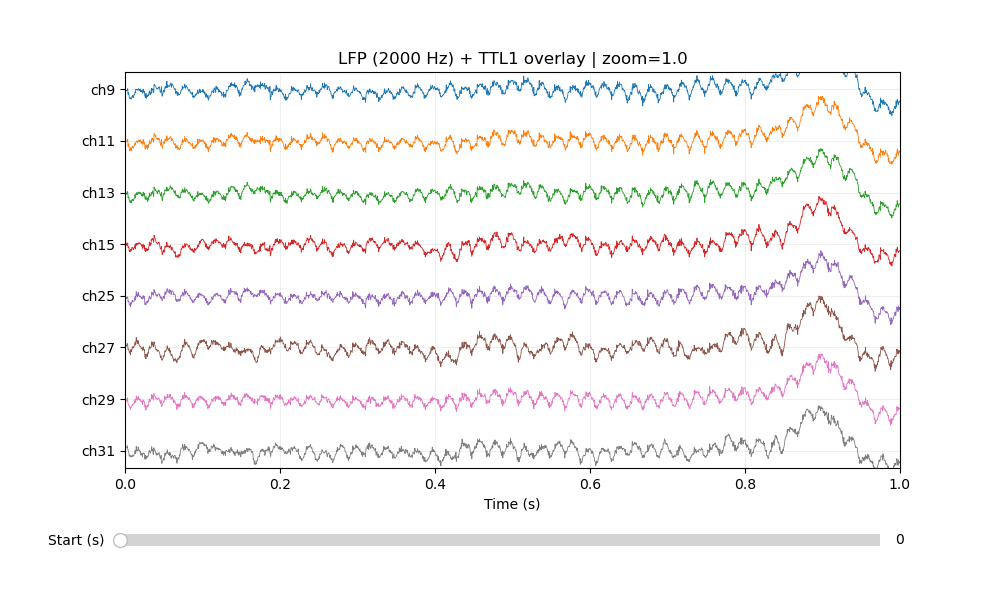

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# In notebook:
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# %matplotlib widget  # if in notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# %matplotlib widget  # in notebook

def plot_stacked_with_ttl1(lfp, fs, pulses_ttl1,
                           start_s=0.0, window_s=10.0,
                           channels=None, label="TTL1",
                           zoom=1.0,    # smaller = zoom in (bigger traces), larger = zoom out
                           sep=3.0      # vertical separation multiplier
                           ):
    n_samp, n_ch = lfp.shape
    if channels is None:
        channels = list(range(min(16, n_ch)))

    pulses_ttl1 = np.asarray(pulses_ttl1) if pulses_ttl1 is not None else np.empty((0, 2), dtype=np.int64)

    fig, ax = plt.subplots(figsize=(10, 6))
    plt.subplots_adjust(bottom=0.22)

    # start-time slider
    ax_sl = fig.add_axes([0.12, 0.08, 0.76, 0.04])
    max_start = max(0.0, (n_samp / fs) - window_s)
    sld = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)

    def render(start_s_local):
        ax.clear()
        i0 = int(start_s_local * fs)
        i1 = min(int((start_s_local + window_s) * fs), n_samp)

        t = np.arange(i0, i1) / fs
        seg = np.asarray(lfp[i0:i1, channels], dtype=np.float32)

        # robust amplitude estimate from data (per window)
        # use 5–95 percentile range, convert to a per-channel "typical" scale
        p5, p95 = np.percentile(seg, [5, 95], axis=0)
        robust_range = np.median(p95 - p5)  # typical peak-to-peak-ish
        if robust_range < 1e-9:
            robust_range = 1.0

        # amp sets both y-zoom and channel spacing
        amp = (robust_range / 2.0) * zoom   # zoom<1 => smaller amp => zoom IN
        offsets = np.arange(len(channels))[::-1] * (amp * sep)

        for k, ch in enumerate(channels):
            ax.plot(t, seg[:, k] + offsets[k], lw=0.6)

        # TTL shading
        if pulses_ttl1.size:
            mask = (pulses_ttl1[:, 1] > i0) & (pulses_ttl1[:, 0] < i1)
            first = True
            for s_idx, e_idx in pulses_ttl1[mask]:
                s = max(s_idx, i0) / fs
                e = min(e_idx, i1) / fs
                ax.axvspan(s, e, alpha=0.15, label=label if first else None)
                first = False

        if ax.get_legend_handles_labels()[1]:
            ax.legend(loc="upper right")

        ax.set_yticks(offsets)
        ax.set_yticklabels([f"ch{c}" for c in channels])
        ax.set_xlim(start_s_local, start_s_local + window_s)
        ax.set_ylim(-amp, offsets[0] + amp)
        ax.set_xlabel("Time (s)")
        ax.set_title(f"LFP ({fs:.0f} Hz) + {label} overlay | zoom={zoom}")
        ax.grid(True, alpha=0.2)
        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()


# --- Call it (TTL1 only) ---
plot_stacked_with_ttl1(
    lfp_raw, fs_raw,
    pulses_ttl1=pulses_idx,   # <- from your TTL1-only extraction code
    start_s=0.0, window_s=1.0,
    channels = [9, 11, 13, 15, 25, 27, 29, 31],
    label="TTL1"
)

#  Downsample all LFP signals to 1 kz.

Downsample ratio: 2
Saving DS to: /Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP/downsample/RawDataChannelExtractedDS.npy
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP/downsample/RawDataChannelExtractedDS.npy exists; loading it (delete to overwrite).
TTL1 pulses DS: (651, 2)


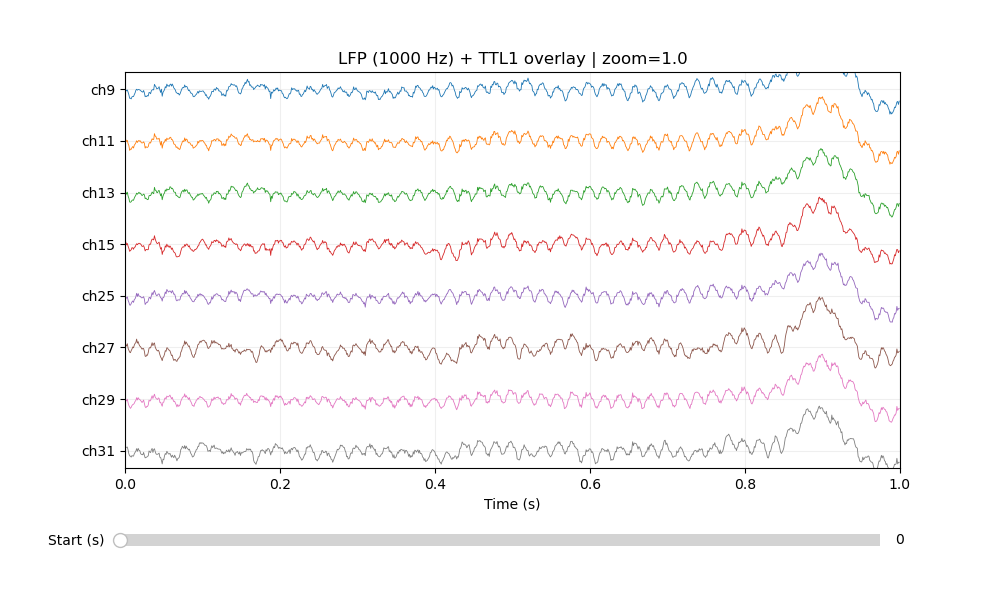

In [60]:
# ============================================================
# Downsample LFP 2kHz -> 1kHz (local), keep TTL1 aligned,
# save RawDataChannelExtractedDS.npy, then visualize again
# ============================================================

import os
import numpy as np
from scipy import signal

# --- SETTINGS ---
fs_raw = 2000.0          # your raw sampling rate
fs_ds  = 1000.0          # target sampling rate
assert fs_raw % fs_ds == 0, "For clean integer-factor downsampling, fs_raw must be multiple of fs_ds"
ratio = int(fs_raw / fs_ds)  # =2

DSname = "RawDataChannelExtractedDS.npy"
local_cache = "/Users/stella/Desktop/PhD/paulsen_lab/Analysis/LFP/downsample"
os.makedirs(local_cache, exist_ok=True)
ds_path = os.path.join(local_cache, DSname)

print("Downsample ratio:", ratio)
print("Saving DS to:", ds_path)

# --- 1) Downsample + save (only if file not already there) ---
if os.path.isfile(ds_path):
    print(f"{ds_path} exists; loading it (delete to overwrite).")
    lfp_ds = np.load(ds_path, mmap_mode="r")
else:
    # lfp_raw can be memmap(int16) or numpy array; convert to float32 for filtering/decimation
    lfp_ds = signal.decimate(
        np.asarray(lfp_raw, dtype=np.float32),
        q=ratio,
        ftype="fir",
        axis=0,
        zero_phase=True
    )
    np.save(ds_path, lfp_ds)
    print("Saved DS with shape:", lfp_ds.shape, "dtype:", lfp_ds.dtype)

# --- 2) Convert TTL1 pulses to DS sample indices (keeps alignment) ---
# pulses_idx is Nx2 in RAW sample indices (fs_raw grid)
pulses_ds = (np.asarray(pulses_idx, dtype=np.int64) // ratio)

# clip to DS bounds (safety)
n_ds = lfp_ds.shape[0]
pulses_ds[:, 0] = np.clip(pulses_ds[:, 0], 0, n_ds - 1)
pulses_ds[:, 1] = np.clip(pulses_ds[:, 1], 0, n_ds - 1)
pulses_ds = pulses_ds[pulses_ds[:, 1] > pulses_ds[:, 0]]

print("TTL1 pulses DS:", pulses_ds.shape)

# --- 3) Visualize again at 1 kHz using your existing viewer ---
plot_stacked_with_ttl1(
    lfp_ds, fs_ds,
    pulses_ttl1=pulses_ds,
    start_s=0.0, window_s=1.0,
  #  channels=list(range(9,16)) + list(range(23,32)),
    channels = [9, 11, 13, 15, 25, 27, 29, 31],
    label="TTL1"
)

Left hemisphere best pair: (25, 27, 0.9208695745040325)
Right hemisphere best pair: (9, 15, 0.9453620995573915)


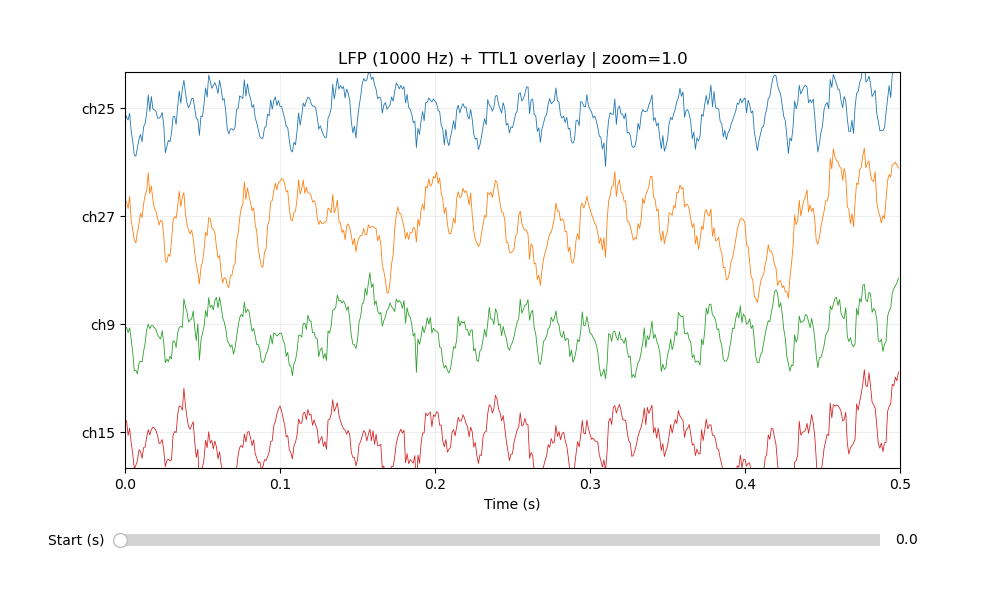

In [58]:
right_ch  = [9, 11, 13, 15]
left_ch = [25, 27, 29, 31]

def most_opposite_pair(lfp, channels, fs, start_s=0, window_s=10):
    i0 = int(start_s * fs)
    i1 = int((start_s + window_s) * fs)
    seg = lfp[i0:i1, channels]

    corr = np.corrcoef(seg.T)

    # find most negative correlation (excluding diagonal)
    np.fill_diagonal(corr, 1.0)
    idx = np.unravel_index(np.argmin(corr), corr.shape)

    ch1 = channels[idx[0]]
    ch2 = channels[idx[1]]
    return ch1, ch2, corr[idx]

pair_L = most_opposite_pair(lfp_ds, left_ch, fs_ds)
pair_R = most_opposite_pair(lfp_ds, right_ch, fs_ds)

print("Left hemisphere best pair:", pair_L)
print("Right hemisphere best pair:", pair_R)

plot_stacked_with_ttl1(
    lfp_ds, fs_ds,
    pulses_ttl1=pulses_ds,
    start_s=0.0, window_s=0.5,
    channels=[pair_L[0], pair_L[1],pair_R[0], pair_R[1]],
    label="TTL1"
)

## End of notebook. 
Data is cleaned up and saved. Data processing for different cortical areas on specific notebooks. Next step is WakeRemoving notebook.

Below is for quick filtering, plotting and visualisation to assess data quality. Filtering for data processing is done again in specific notebooks.

Data quality is assessed on a Sample, whose value has to be attributed on the initial cell.

## Filtering 

SWR: 120 - 250 Hz

Wn: [0.24, 0.5]


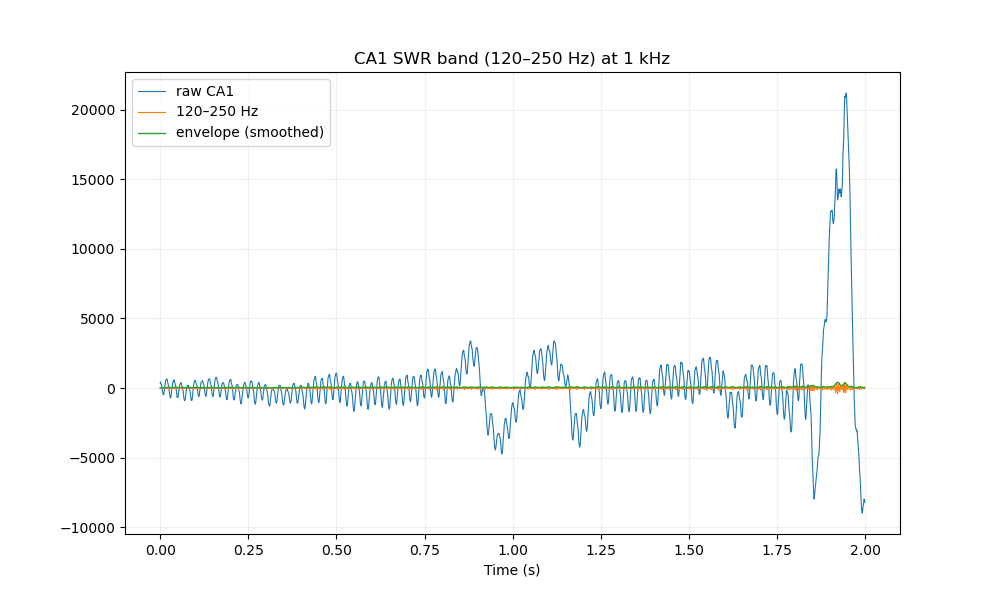

In [28]:
import numpy as np
import scipy
from scipy import signal
import matplotlib.pyplot as plt

# Use your downsampled data (shape: time x channels)
# If you loaded from file:
# lfp_ds = np.load(ds_path, mmap_mode="r")

Sample = lfp_ds              # <-- make sure this is your 1 kHz data
fs = fs_ds                   # should be 1000.0

ch_ca1 = 3                   # you used channel 3
x = np.asarray(Sample[:, ch_ca1], dtype=np.float32)

# ----------------------------
# 1) Bandpass filter 120–250 Hz
# ----------------------------
f_lowcut = 120.0
f_hicut  = 250.0
nyq = 0.5 * fs
Wn = [f_lowcut/nyq, f_hicut/nyq]
print("Wn:", Wn)

# Use SOS form for numerical stability (recommended)
sos = signal.butter(N=6, Wn=Wn, btype="bandpass", output="sos")
x_swr = signal.sosfiltfilt(sos, x)

# ----------------------------
# 2) SWR envelope (Hilbert)
# ----------------------------
env = np.abs(signal.hilbert(x_swr))

# optional: smooth envelope a bit (e.g. 10 ms)
smooth_ms = 10
win = int(fs * smooth_ms / 1000)
if win >= 3:
    kernel = np.ones(win) / win
    env_smooth = np.convolve(env, kernel, mode="same")
else:
    env_smooth = env

# ----------------------------
# 3) Plot a window
# ----------------------------
start_s = 0.0
window_s = 2.0
i0 = int(start_s * fs)
i1 = int((start_s + window_s) * fs)

t = np.arange(i0, i1) / fs

plt.figure(figsize=(10, 6))
plt.plot(t, x[i0:i1], label="raw CA1", linewidth=0.8)
plt.plot(t, x_swr[i0:i1], label="120–250 Hz", linewidth=0.8)
plt.plot(t, env_smooth[i0:i1], label="envelope (smoothed)", linewidth=1.0)
plt.xlabel("Time (s)")
plt.title("CA1 SWR band (120–250 Hz) at 1 kHz")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


[global max] idx=14079 time=14.079s env=1814.278


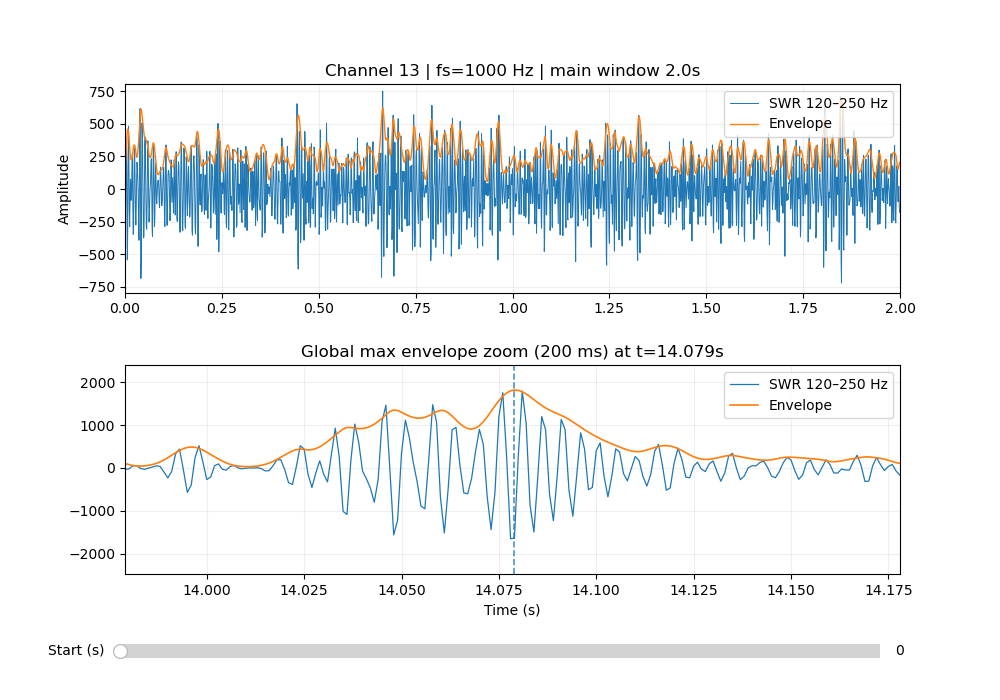

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from scipy import signal

# %matplotlib widget

def swr_viewer_globalmax(
    lfp_ds, fs=1000.0, ch=3,
    band=(120, 250), order=6,
    start_s=0.0,
    window_s=2.0,
    zoom_ms=50,
    env_smooth_ms=10,
    y_mode="percentile",   # "percentile" or "fixed"
    y_fixed=2000
):
    """
    Top panel (slider-controlled): SWR-band + envelope (no raw trace)
    Bottom panel (fixed): 50 ms zoom around the GLOBAL maximum envelope peak
    """

    x = np.asarray(lfp_ds[:, ch], dtype=np.float32)
    n = x.size

    # ---- SWR bandpass (entire trace) ----
    nyq = 0.5 * fs
    Wn = [band[0] / nyq, band[1] / nyq]
    sos = signal.butter(order, Wn, btype="bandpass", output="sos")
    x_swr = signal.sosfiltfilt(sos, x)

    # ---- envelope (entire trace) ----
    env = np.abs(signal.hilbert(x_swr))
    win = int(fs * env_smooth_ms / 1000.0)
    if win >= 3:
        env = np.convolve(env, np.ones(win) / win, mode="same")

    # ---- global max peak index (entire trace) ----
    peak_idx = int(np.argmax(env))
    peak_t = peak_idx / fs
    print(f"[global max] idx={peak_idx} time={peak_t:.3f}s env={env[peak_idx]:.3f}")

    # ---- compute global zoom window once ----
    zoom_s = zoom_ms / 1000.0
    zoom_len = max(1, int(round(zoom_s * fs)))
    zoom_half = zoom_len // 2

    z0 = peak_idx - zoom_half
    z1 = z0 + zoom_len
    if z0 < 0:
        z0 = 0
        z1 = min(n, zoom_len)
    if z1 > n:
        z1 = n
        z0 = max(0, n - zoom_len)

    tz = np.arange(z0, z1) / fs
    swr_z = x_swr[z0:z1]
    env_z = env[z0:z1]

    # ---- plotting helpers ----
    def set_ylim(ax, seg):
        if y_mode == "fixed":
            ax.set_ylim(-y_fixed, y_fixed)
        elif y_mode == "percentile":
            lo, hi = np.percentile(seg, [1, 99])
            pad = 0.3 * (hi - lo + 1e-9)
            ax.set_ylim(lo - pad, hi + pad)
        else:
            raise ValueError("y_mode must be 'fixed' or 'percentile'")

    # ---- figure + slider ----
    fig, (ax_main, ax_zoom) = plt.subplots(2, 1, figsize=(10, 7))
    plt.subplots_adjust(bottom=0.18, hspace=0.35)

    ax_sl = fig.add_axes([0.12, 0.05, 0.76, 0.04])
    max_start = max(0.0, (n / fs) - window_s)
    sld = Slider(ax_sl, "Start (s)", 0.0, max_start, valinit=start_s)

    # ---- draw zoom panel ONCE (global max) ----
    ax_zoom.plot(tz, swr_z, lw=0.9, label=f"SWR {band[0]}–{band[1]} Hz")
    ax_zoom.plot(tz, env_z, lw=1.2, label="Envelope")
    ax_zoom.axvline(peak_t, ls="--", lw=1.2, alpha=0.8)
    ax_zoom.set_xlim(tz[0], tz[-1])
    ax_zoom.set_title(f"Global max envelope zoom ({zoom_ms} ms) at t={peak_t:.3f}s")
    ax_zoom.set_xlabel("Time (s)")
    ax_zoom.grid(True, alpha=0.2)
    ax_zoom.legend(loc="upper right")
    # y limits for zoom based on SWR trace (since we don't plot raw)
    set_ylim(ax_zoom, swr_z)

    # ---- main render (slider-controlled) ----
    def render(s0):
        ax_main.clear()

        i0 = int(s0 * fs)
        i1 = min(int((s0 + window_s) * fs), n)

        t = np.arange(i0, i1) / fs
        swr_seg = x_swr[i0:i1]
        env_seg = env[i0:i1]

        ax_main.plot(t, swr_seg, lw=0.7, label=f"SWR {band[0]}–{band[1]} Hz")
        ax_main.plot(t, env_seg, lw=1.0, label="Envelope")

        # mark the global max location if it falls within this window
        if (peak_idx >= i0) and (peak_idx < i1):
            ax_main.axvline(peak_t, ls="--", lw=1.2, alpha=0.8)

        ax_main.set_xlim(s0, s0 + window_s)
        ax_main.set_title(f"Channel {ch} | fs={fs:.0f} Hz | main window {window_s:.1f}s")
        ax_main.set_ylabel("Amplitude")
        ax_main.grid(True, alpha=0.2)
        ax_main.legend(loc="upper right")
        set_ylim(ax_main, swr_seg)

        fig.canvas.draw_idle()

    sld.on_changed(lambda v: render(sld.val))
    render(start_s)
    plt.show()


# ---- Run it ----
swr_viewer_globalmax(
    lfp_ds,
    fs=fs_ds,
    ch=13,
    band=(120, 250),
    window_s=2.0,
    zoom_ms=200,
    env_smooth_ms=10,
    y_mode="percentile"   # or "fixed"
    # y_fixed=2000
)

Spindles: 8 - 16 Hz

In [ ]:
f_PFC = Sample[:, 1].copy()
f_S1 = Sample[:, 2].copy()

# Paramètres de notre filtre :
f_lowcut = 10.
f_hicut = 16.
Wn = [f_lowcut/nyq,f_hicut/nyq]  # Nyquist frequency fraction
N = 4
# Création du filtre :
b, a = scipy.signal.butter(N, Wn, 'band')
filt_Spind_PFC = scipy.signal.filtfilt(b, a, f_PFC)
filt_Spind_S1 = scipy.signal.filtfilt(b, a, f_S1)

# # Calcul de la reponse en fréquence du filtre
# w, h = signal.freqz(b, a)

# # Tracé de la réponse en fréquence du filtre
# fig, ax = plt.subplots(figsize=(8,5)) 

# ax.plot(0.5*fs*w/np.pi, np.abs(h), 'b')

# ax.set_xlabel('frequency [Hz]')
# ax.set_ylabel('Amplitude [dB]')
# ax.grid(which='both', axis='both')

FFT display

In [ ]:
# Calcul du spectre
f, Pxx_den = signal.welch(f_CA1, fs, nperseg=1024)

# Tracé
fig, ax = plt.subplots(figsize=(10,5)) 
ax.semilogy(f, Pxx_den)   #  plot with log scaling on the y axis
ax.set_xlabel('frequency [Hz]')
ax.set_ylabel('PSD [V**2/Hz]')

In [ ]:
plt.close('all')

# Display. 

Can massively be improved: with Matplotlib

In [ ]:
times_sliced = times[000:200000]
filt_to_display = filt_SWR_CA1[000:200000]-1000
f_CA1_sliced = f_CA1[0000:200000]/2
combined = np.stack((f_CA1_sliced, filt_to_display), axis = 1)
# Tracé du signal filtré

fig, ax = plt.subplots(1,1, figsize=(15,5), layout='constrained') 
ax.plot(times_sliced, combined, 'r')
ax.set_xlabel('Temps [sec]')
ax.set_ylabel('Amplitude')


With ephyviewer. 

In [ ]:
# prepare numpy array for ephyviewer

filt_SWR_CA1_sliced= filt_SWR_CA1[000:200000, np.newaxis]
filt_Spind_PFC_sliced= filt_Spind_PFC[000:200000, np.newaxis]
filt_Spind_S1_sliced= filt_Spind_S1[000:200000, np.newaxis]
filt_sliced = Sample[0000:200000,:]
combined2 = filt_sliced[:,0:2].copy()
intf_sliced = filt_sliced[:,2]
intf_sliced = intf_sliced[:, np.newaxis]
combined2 = np.append(combined2, filt_Spind_PFC_sliced, axis=1)
combined2 = np.append(combined2, intf_sliced, axis=1)
combined2 = np.append(combined2, filt_Spind_S1_sliced, axis=1)
intf_sliced = filt_sliced[:,3]
intf_sliced = intf_sliced[:, np.newaxis]
combined2 = np.append(combined2, intf_sliced, axis=1)
combined2 = np.append(combined2, filt_SWR_CA1_sliced, axis = 1)


In [ ]:
%gui qt 
app = mkQApp()

sample_rate = 1000.
t_start = 0.

#Create the main window that can contain several viewers
win = MainViewer()
view1 = TraceViewer.from_numpy(combined2, sample_rate, t_start, 'Signals')
win.add_view(view1)

#Parameters can be set in script
view1.params['display_labels'] = True
view1.params['scale_mode'] = 'same_for_all'
view1.auto_scale()

#Run
win.show()